## Online Retail Sales Analysis

#### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## EDA Task

#### Data Connectivity


In [2]:
sales=pd.read_csv(r"G:\Python Project\Online Sales Dataset.csv",encoding = 'latin')
sales

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


#### Data Manupulation

In [3]:
sales.shape

(541909, 8)

In [4]:
sales.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [5]:
sales.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [6]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [7]:
sales.dtypes

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

In [8]:
sales['InvoiceDate']=pd.to_datetime(sales['InvoiceDate'])

In [9]:
sales.dtypes

InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

In [10]:
sales.drop_duplicates(inplace=True)
sales

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [11]:
sales.duplicated().sum()

np.int64(0)

## 1. Basic Data Understanding

##### Display the first 10 rows 


In [12]:
sales.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


##### Display the last 5 rows


In [13]:
sales.tail(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


##### Find the number of unique 


In [14]:
sales['InvoiceNo'].nunique()

25900

##### Find the number of unique 


In [15]:
sales['CustomerID'].nunique()

4372

##### Find the unique countries in the dataset


In [16]:
sales['Country'].unique()

<StringArray>
[      'United Kingdom',               'France',            'Australia',
          'Netherlands',              'Germany',               'Norway',
                 'EIRE',          'Switzerland',                'Spain',
               'Poland',             'Portugal',                'Italy',
              'Belgium',            'Lithuania',                'Japan',
              'Iceland',      'Channel Islands',              'Denmark',
               'Cyprus',               'Sweden',              'Austria',
               'Israel',              'Finland',              'Bahrain',
               'Greece',            'Hong Kong',            'Singapore',
              'Lebanon', 'United Arab Emirates',         'Saudi Arabia',
       'Czech Republic',               'Canada',          'Unspecified',
               'Brazil',                  'USA',   'European Community',
                'Malta',                  'RSA']
Length: 38, dtype: str

## 2. Data Cleaning

##### Check for missing values in each column.


In [17]:
sales.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
dtype: int64

##### Find the number of duplicate rows


In [18]:
sales.duplicated().sum()

np.int64(0)

##### Remove duplicate rows


In [19]:
sales.drop_duplicates(inplace=True)

##### Find rows where Description is missing


In [20]:
sales[sales['Description'].isnull()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535322,581199,84581,NaN,-2,2011-12-07 18:26:00,0.0,NaN,United Kingdom
535326,581203,23406,NaN,15,2011-12-07 18:31:00,0.0,NaN,United Kingdom
535332,581209,21620,NaN,6,2011-12-07 18:35:00,0.0,NaN,United Kingdom
536981,581234,72817,NaN,27,2011-12-08 10:33:00,0.0,NaN,United Kingdom


In [56]:
sales['Description'] = sales['Description'].fillna('Unknown')

In [59]:
sales['Description'].isnull().sum()

np.int64(0)

##### Find rows where CustomerID is missing


In [21]:
sales[sales['CustomerID'].isnull()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
541536,581498,85099B,JUMBO BAG RED RETROSPOT,5,2011-12-09 10:26:00,4.13,NaN,United Kingdom
541537,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,2011-12-09 10:26:00,4.13,NaN,United Kingdom
541538,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,2011-12-09 10:26:00,4.96,NaN,United Kingdom
541539,581498,85174,S/4 CACTI CANDLES,1,2011-12-09 10:26:00,10.79,NaN,United Kingdom


##### Convert InvoiceDate from object/string to datetime


In [22]:
sales['InvoiceDate']=pd.to_datetime(sales['InvoiceDate'])

##### Define Month And Day Name

In [23]:
sales['Month'] = sales['InvoiceDate'].dt.month_name()
sales['Day'] = sales['InvoiceDate'].dt.day_name()
sales.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Month,Day
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,December,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,December,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,December,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,December,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,December,Wednesday


##### Correct incorrect values in the Country column


In [24]:
sales['Country']=sales['Country'].str.strip().str.title()
sales.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Month,Day
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,December,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,December,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,December,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,December,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,December,Wednesday


In [25]:
sales.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Month', 'Day'],
      dtype='str')

##### Check whether Quantity And UnitPrice contains negative values


In [26]:
(sales['Quantity']<0).sum()

np.int64(10587)

In [27]:
(sales['UnitPrice'] <=0).sum()

np.int64(2512)

#####  Filter all negative values and then replace with 0


In [28]:
sales.loc[sales['Quantity'] < 0, 'Quantity'] = 0
sales.loc[sales['UnitPrice'] < 0, 'UnitPrice'] = 0

##### Save The Cleaned Datatset

In [75]:
sales.to_csv('Online Retail Sales Clean Dataset.csv',index=False)

##### Call Clean Dataset

In [76]:
sales=pd.read_csv('Online Retail Sales Clean Dataset.csv')
sales

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Month,Day,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,December,Wednesday,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,December,Wednesday,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,December,Wednesday,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,December,Wednesday,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,December,Wednesday,20.34
...,...,...,...,...,...,...,...,...,...,...,...
536636,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,December,Friday,10.20
536637,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,December,Friday,12.60
536638,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,December,Friday,16.60
536639,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,December,Friday,16.60


## 3. Data Analysis

In [31]:
sales.describe()

,Quantity,UnitPrice,CustomerID
count,536641.000000,536641.000000,401604.000000
mean,10.519172,4.673883,15281.160818
std,156.036720,94.856938,1714.006089
min,0.000000,0.000000,12346.000000
25%,1.000000,1.250000,13939.000000
50%,3.000000,2.080000,15145.000000
75%,10.000000,4.130000,16784.000000
max,80995.000000,38970.000000,18287.000000


##### Find The Total Quantity Sold


In [32]:
Total_Quantity=sales['Quantity'].sum()
print(Total_Quantity)

5645019


##### Find The Average UnitPrice


In [33]:
Avg_UnitPrice=sales['UnitPrice'].mean()
print(Avg_UnitPrice)

4.673882714887607


##### Find The Maximum Quantity Purchased In a Single Transaction


In [34]:
Max_Quantity=sales['Quantity'].max()
print(Max_Quantity)

80995


##### Find The Minimum And Maximum UnitPrice


In [35]:
Min_UnitPrice=sales['UnitPrice'].min()
Max_UnitPrice=sales['UnitPrice'].max()
print(Min_UnitPrice)
print(Max_UnitPrice)

0.0
38970.0


##### Find The Top 10 Products Based On Quantity Sold.


In [36]:
Top_Product=sales.groupby('Description')['Quantity'].sum().sort_values(ascending=False).reset_index().head(10)
Top_Product

,Description,Quantity
0,"PAPER CRAFT , LITTLE BIRDIE",80995
1,MEDIUM CERAMIC TOP STORAGE JAR,78033
2,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951
3,JUMBO BAG RED RETROSPOT,48375
4,WHITE HANGING HEART T-LIGHT HOLDER,37876
5,POPCORN HOLDER,36749
6,PACK OF 72 RETROSPOT CAKE CASES,36396
7,ASSORTED COLOUR BIRD ORNAMENT,36362
8,RABBIT NIGHT LIGHT,30739
9,MINI PAINT SET VINTAGE,26633


##### Find The Top 5 Countries Based On Number Of Transactions


In [37]:
Top_Country=sales.groupby('Country').size().sort_values(ascending=False).reset_index().head(5)
Top_Country

,Country,0
0,United Kingdom,490300
1,Germany,9480
2,France,8541
3,Eire,8184
4,Spain,2528


##### Find The Customer Who Purchased The Highest Quantity


In [38]:
Customer=sales.groupby('CustomerID')['Quantity'].sum().sort_values(ascending=False).reset_index().head(1)
Customer

,CustomerID,Quantity
0,14646.0,197491


##### Find The Most Frequently Purchased Product


In [39]:
MostPurchased_Product=sales.groupby('Description')['Quantity'].sum().sort_values(ascending=False).reset_index().head(1)
MostPurchased_Product

,Description,Quantity
0,"PAPER CRAFT , LITTLE BIRDIE",80995


##### Add TotalAmount Column

In [40]:
sales['TotalAmount']=sales['Quantity'] * sales['UnitPrice']
sales.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Month,Day,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,December,Wednesday,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,December,Wednesday,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,December,Wednesday,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,December,Wednesday,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,December,Wednesday,20.34


##### Find The Total Sales/Revenue


In [41]:
Total_Sales=sales['TotalAmount'].sum().round(2)
print(Total_Sales)

10642110.8


##### Find The Average Order Value


In [42]:
Avg_Order=sales['Quantity'].mean().round(2)
print(Avg_Order)

10.52


##### Find Total Sales By Country

In [43]:
Country_Total_Sales=sales.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).reset_index()
Country_Total_Sales

,Country,TotalAmount
0,United Kingdom,9001744.094
1,Netherlands,285446.340
2,Eire,283140.520
3,Germany,228678.400
4,France,209625.370
5,Australia,138453.810
6,Spain,61558.560
7,Switzerland,57067.600
8,Belgium,41196.340
9,Sweden,38367.830


##### Find Total Sales By Month


In [44]:
Month_Total_Sales = sales.groupby('Month')['TotalAmount'].sum()
Month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

Month_Total_Sales = Month_Total_Sales.reindex(Month_order).reset_index()
Month_Total_Sales

,Month,TotalAmount
0,January,689811.610
1,February,522545.560
2,March,716215.260
3,April,536968.491
4,May,769296.610
5,June,760547.010
6,July,718076.121
7,August,757841.380
8,September,1056435.192
9,October,1151263.730


## Visualization

##### Create A BoxPlot For Quantity


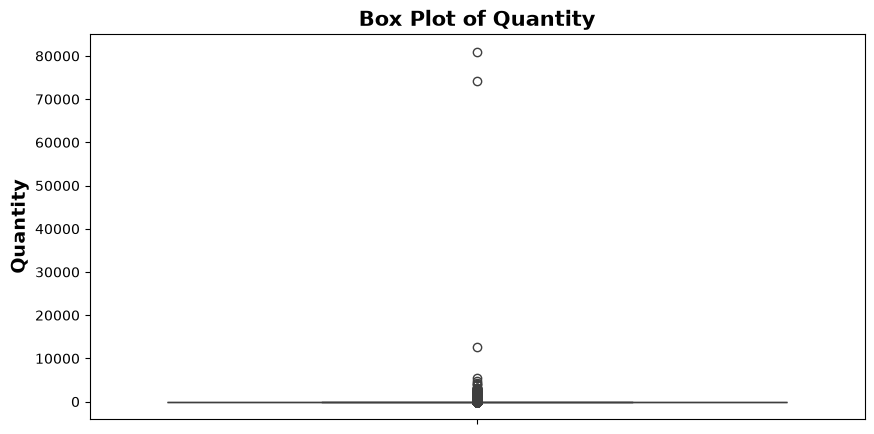

In [45]:
plt.figure(figsize=(10,5))
sns.boxplot(data=sales, y='Quantity')
plt.title('Box Plot of Quantity',fontsize=15,fontweight='bold')
plt.ylabel('Quantity', fontsize=14, fontweight='bold')

plt.show()


##### Create A BoxPlot For UnitPrice


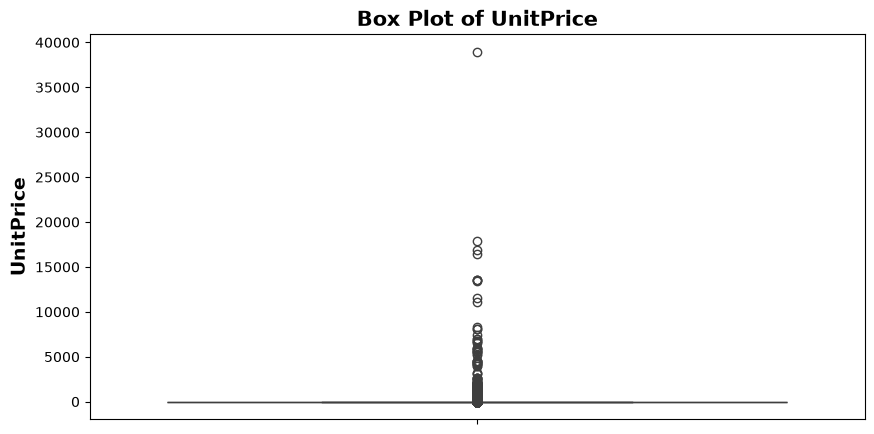

In [46]:
plt.figure(figsize=(10,5))
x=sns.boxplot(data=sales,y='UnitPrice')
plt.title("Box Plot of UnitPrice",fontsize=15,fontweight='bold')
plt.ylabel('UnitPrice', fontsize=14, fontweight='bold')

plt.show()
              

##### Create A Bar Chart Of The Top 10 Products By Sales


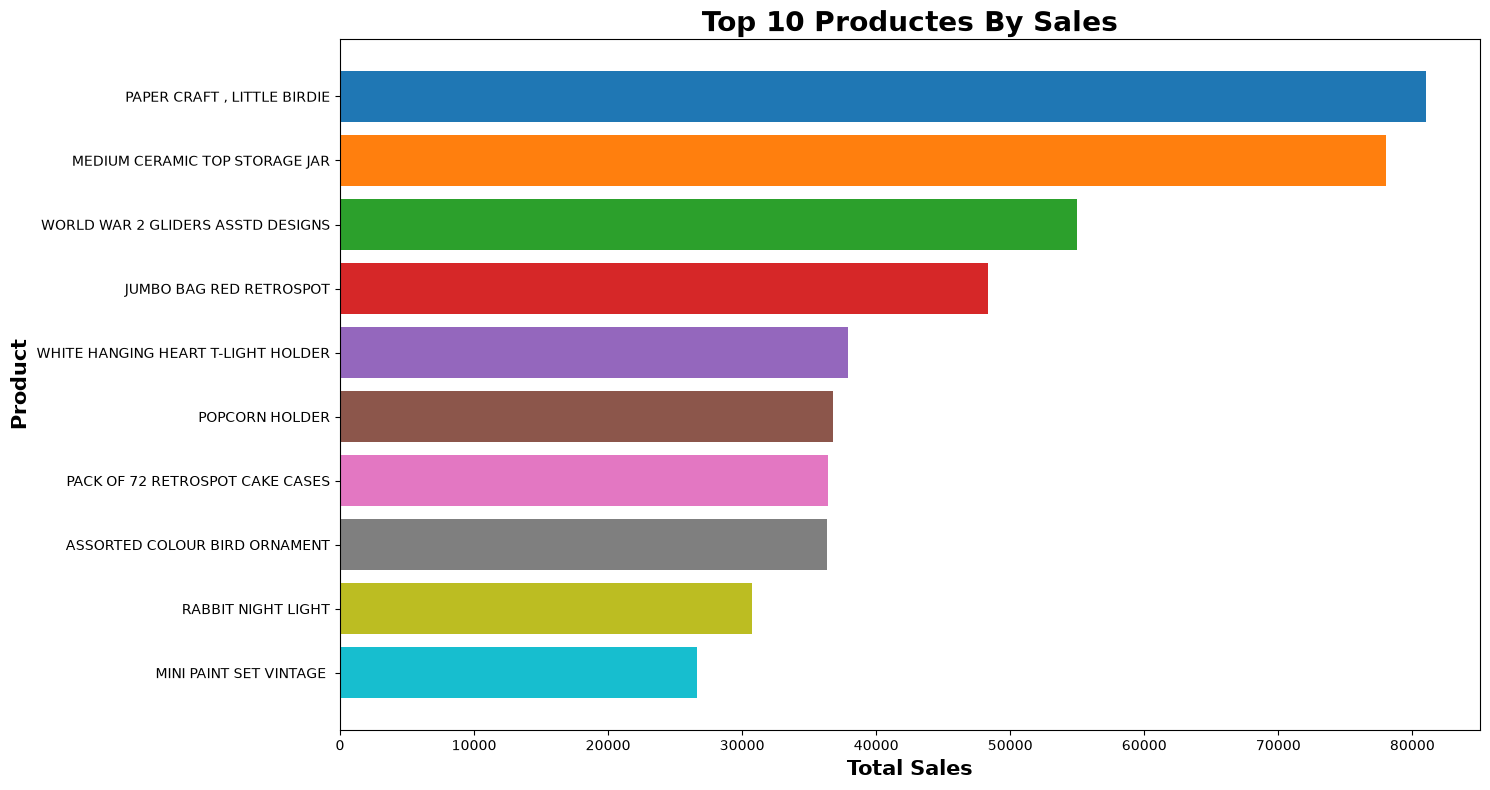

In [73]:
plt.figure(figsize=(15,8))
plt.barh(Top_Product['Description'],Top_Product['Quantity'],color=plt.cm.tab10(range(10)))
plt.xlabel('Total Sales',fontsize=15,fontweight='bold')
plt.ylabel('Product',fontsize=15,fontweight='bold')
plt.title('Top 10 Productes By Sales',fontsize=20,fontweight='bold')
plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

##### Create A Line Chart For Monthly Sales


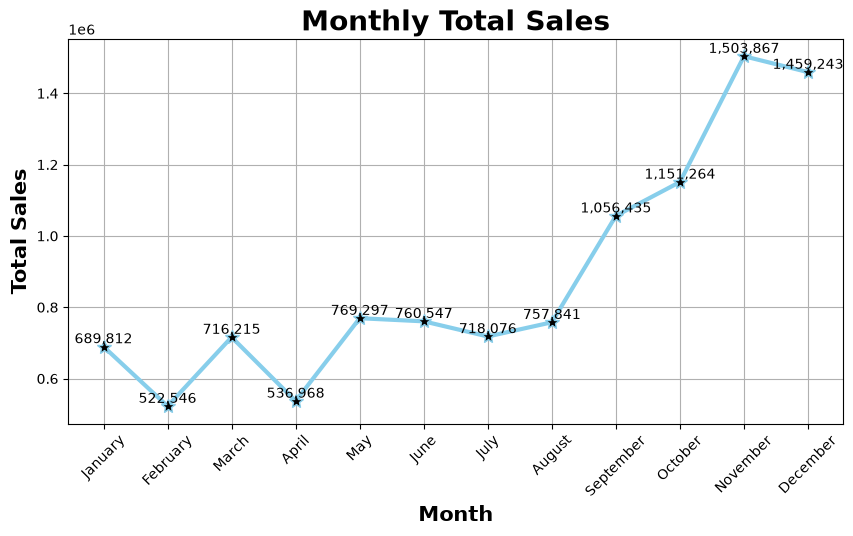

In [48]:

plt.figure(figsize=(10, 5))

plt.plot(
    Month_Total_Sales['Month'],
    Month_Total_Sales['TotalAmount'],
    marker='*', markersize=10,markerfacecolor='k',
    linewidth=3,color='skyblue'
)

# Values show karne ke liye
for x, y in zip(Month_Total_Sales['Month'], Month_Total_Sales['TotalAmount']):
    plt.text(x, y, f'{y:,.0f}', ha='center', va='bottom', fontsize=10,color='black')

plt.title('Monthly Total Sales',fontsize=20,fontweight='bold')
plt.xlabel('Month',fontsize=15,fontweight='bold')
plt.ylabel('Total Sales',fontsize=15,fontweight='bold')

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

##### Create A Bar Chart Showing Sales By Country


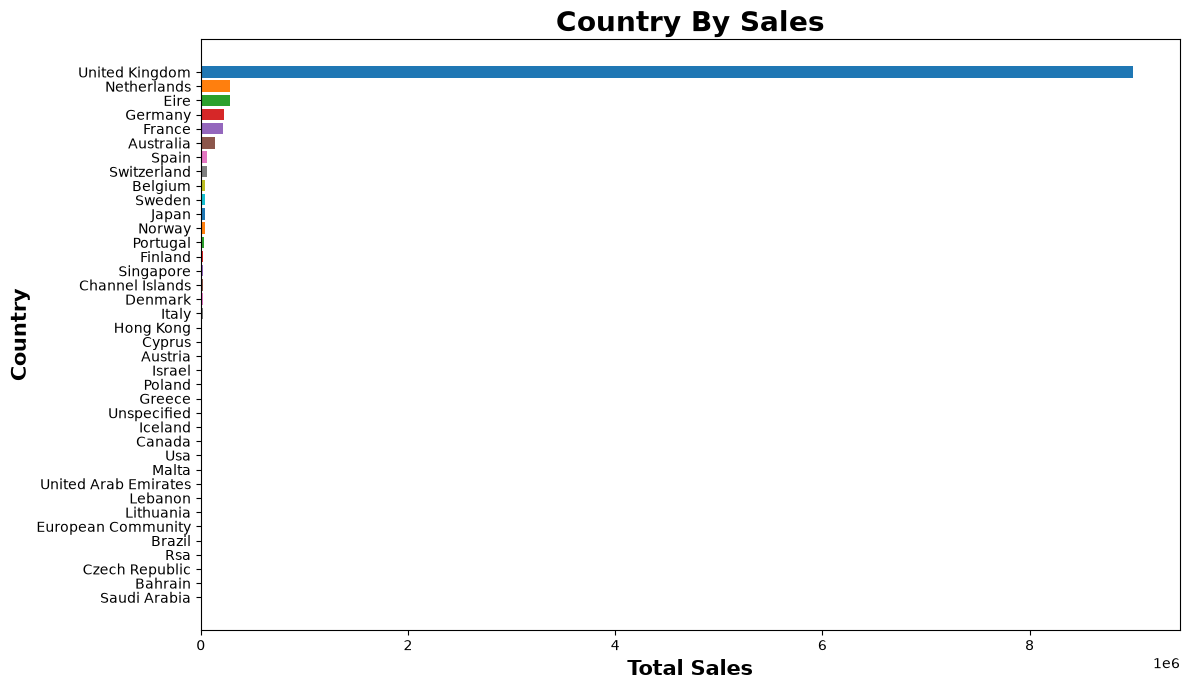

In [49]:
plt.figure(figsize=(12,7))
plt.barh(Country_Total_Sales['Country'],Country_Total_Sales['TotalAmount'],color=plt.cm.tab10(range(10)))
plt.xlabel('Total Sales',fontsize=15,fontweight='bold')
plt.ylabel('Country',fontsize=15,fontweight='bold')
plt.title('Country By Sales',fontsize=20,fontweight='bold')
plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()